# Global Warming Monitor — Forecasting Pipeline

Re-parses the raw climate series in `data/`, explores them (EDA), then backtests
and forecasts each to 2050. Forecast JSON is written to `docs/public/ml_files/`
for the dashboard to consume.

**Series:** CO₂ (Mauna Loa) · GISTEMP · emissions · Arctic sea ice · US electricity emissions by fuel

In [4]:
# ── Setup & config ──────────────────────────────────────────────────────────
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

# Paths (notebook lives at repo root)
DATA_DIR = pathlib.Path("data")
OUT_DIR  = pathlib.Path("docs") / "public" / "ml_files"

# Pipeline config
HORIZON_YEAR   = 2050   # forecast out to here
BACKTEST_SPLIT = 2010   # train <= this year, validate after
RANDOM_STATE   = 42

print("pandas", pd.__version__, "| numpy", np.__version__)
print("sklearn", __import__("sklearn").__version__, "| statsmodels", sm.__version__)

pandas 2.3.3 | numpy 2.5.1
sklearn 1.9.0 | statsmodels 0.14.6


In [ ]:
#------ 
def parse_seaice(path=DATA_DIR / "seaice_monyear_G02135_v4.0.xlsx"):
    """NSIDC G02135 NH sea-ice extent (M km²). Wide (year × full month names) → long."""
    wide = pd.read_excel(path, sheet_name="NH-Extent", engine="openpyxl")
    year_col = wide.columns[0]
    full_months = ["January","February","March","April","May","June",
                   "July","August","September","October","November","December"]
    wide = wide[pd.to_numeric(wide[year_col], errors="coerce").notna()].copy()
    wide[year_col] = wide[year_col].astype(int)
    long = wide.melt(id_vars=year_col, var_name="month", value_name="extent")
    long = long[long["month"].isin(full_months)]
    long["month"] = long["month"].map({m: i + 1 for i, m in enumerate(full_months)})
    long["date"] = pd.to_datetime(
        dict(year=long[year_col], month=long["month"], day=1))
    long["extent"] = pd.to_numeric(long["extent"], errors="coerce")
    return long[["date", "extent"]].set_index("date").sort_index()

In [12]:
# ── Run parsers & validate ──────────────────────────────────────────────────
co2              = parse_co2()
gistemp, gis_ann = parse_gistemp()
emissions        = parse_emissions()
seaice           = parse_seaice()
emissions_by_ind = parse_emissions_by_ind()

def audit(name, df, value_cols):
    span = f"{df.index.min():%Y-%m} → {df.index.max():%Y-%m}"
    nan  = {c: int(df[c].isna().sum()) for c in value_cols}
    print(f"{name:18s} rows={len(df):5d}  {span}  NaN={nan}")

audit("co2",              co2,              ["average", "deseasonalized"])
audit("gistemp (monthly)", gistemp,         ["anomaly"])
audit("gistemp (annual)",  gis_ann,         ["anomaly"])
audit("emissions",        emissions,        ["emissions_gt"])
audit("seaice",           seaice,           ["extent"])
audit("emissions_by_ind", emissions_by_ind, list(emissions_by_ind.columns))

co2                rows=  810  1959-01 → 2026-06  NaN={'average': 0, 'deseasonalized': 0}
gistemp (monthly)  rows= 1764  1880-01 → 2026-12  NaN={'anomaly': 7}
gistemp (annual)   rows=  147  1880-01 → 2026-01  NaN={'anomaly': 1}
emissions          rows=  275  1750-01 → 2024-01  NaN={'emissions_gt': 0}
seaice             rows=  588  1978-01 → 2026-12  NaN={'extent': 18}
emissions_by_ind   rows=   35  1990-01 → 2024-01  NaN={'coal': 0, 'gas': 0, 'petroleum': 0, 'other': 0}


c:\Users\sendt\anaconda3\envs\CS4200\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


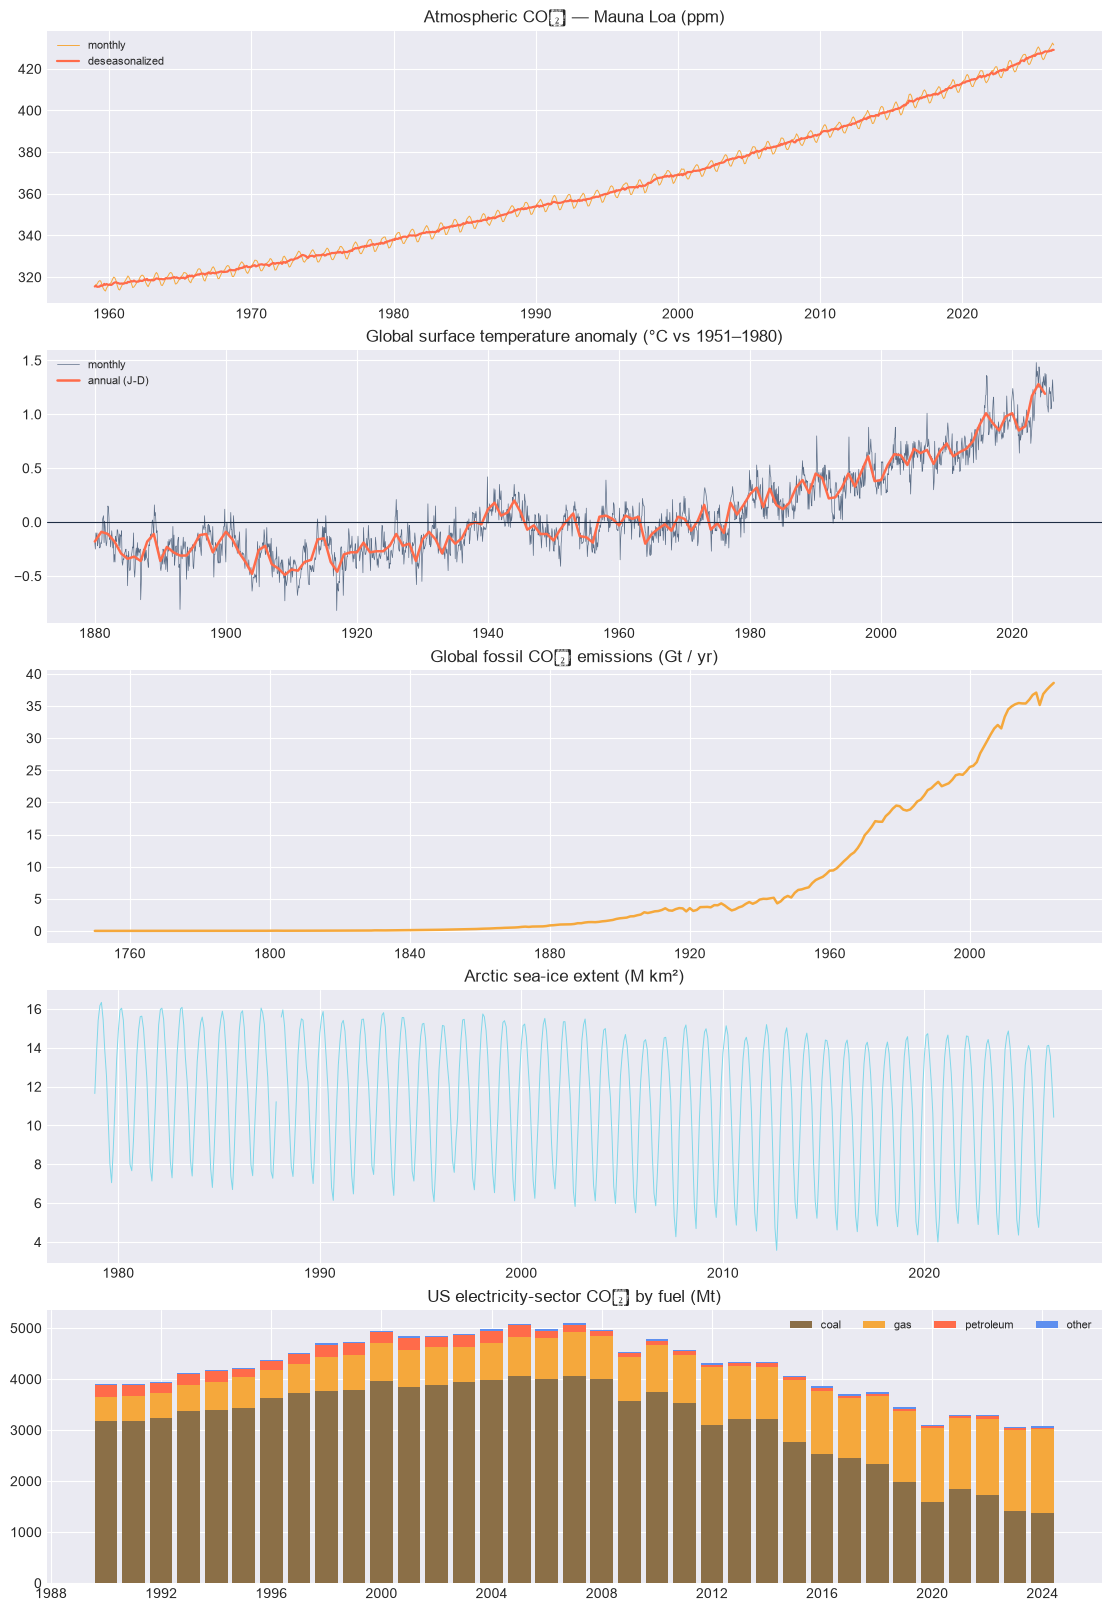

In [13]:
# ── EDA: series overview ────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(11, 16), constrained_layout=True)

axes[0].plot(co2.index, co2["average"], lw=0.7, color="#f5a83c", label="monthly")
axes[0].plot(co2.index, co2["deseasonalized"], lw=1.6, color="#ff6b4a",
             label="deseasonalized")
axes[0].set_title("Atmospheric CO₂ — Mauna Loa (ppm)")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].plot(gistemp.index, gistemp["anomaly"], lw=0.5, color="#5b6d86",
             label="monthly")
axes[1].plot(gis_ann.index, gis_ann["anomaly"], lw=1.8, color="#ff6b4a",
             label="annual (J-D)")
axes[1].axhline(0, color="#1e2d44", lw=0.8)
axes[1].set_title("Global surface temperature anomaly (°C vs 1951–1980)")
axes[1].legend(loc="upper left", fontsize=8)

axes[2].plot(emissions.index, emissions["emissions_gt"], lw=1.8, color="#f5a83c")
axes[2].set_title("Global fossil CO₂ emissions (Gt / yr)")

axes[3].plot(seaice.index, seaice["extent"], lw=0.7, color="#7fd8ea")
axes[3].set_title("Arctic sea-ice extent (M km²)")

bottoms = np.zeros(len(emissions_by_ind))
for fuel, color in [("coal", "#8b6f47"), ("gas", "#f5a83c"),
                    ("petroleum", "#ff6b4a"), ("other", "#5e8fef")]:
    axes[4].bar(emissions_by_ind.index, emissions_by_ind[fuel], bottom=bottoms,
                width=300, label=fuel, color=color)
    bottoms += emissions_by_ind[fuel].to_numpy()
axes[4].set_title("US electricity-sector CO₂ by fuel (Mt)")
axes[4].legend(loc="upper right", fontsize=8, ncol=4)

plt.show()

Augmented Dickey-Fuller (level series)
──────────────────────────────────────────────
co2.deseasonalized         ADF p=1.0000  → NON-stationary → difference
gistemp.anomaly            ADF p=0.9581  → NON-stationary → difference
emissions.emissions_gt     ADF p=1.0000  → NON-stationary → difference
seaice.extent              ADF p=0.7336  → NON-stationary → difference

Linear trend (full record)
──────────────────────────────────────────────
co2.deseasonalized         +16.792 / decade
gistemp.anomaly            +0.084 / decade
emissions.emissions_gt     +1.068 / decade
seaice.extent              -0.505 / decade


c:\Users\sendt\anaconda3\envs\CS4200\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


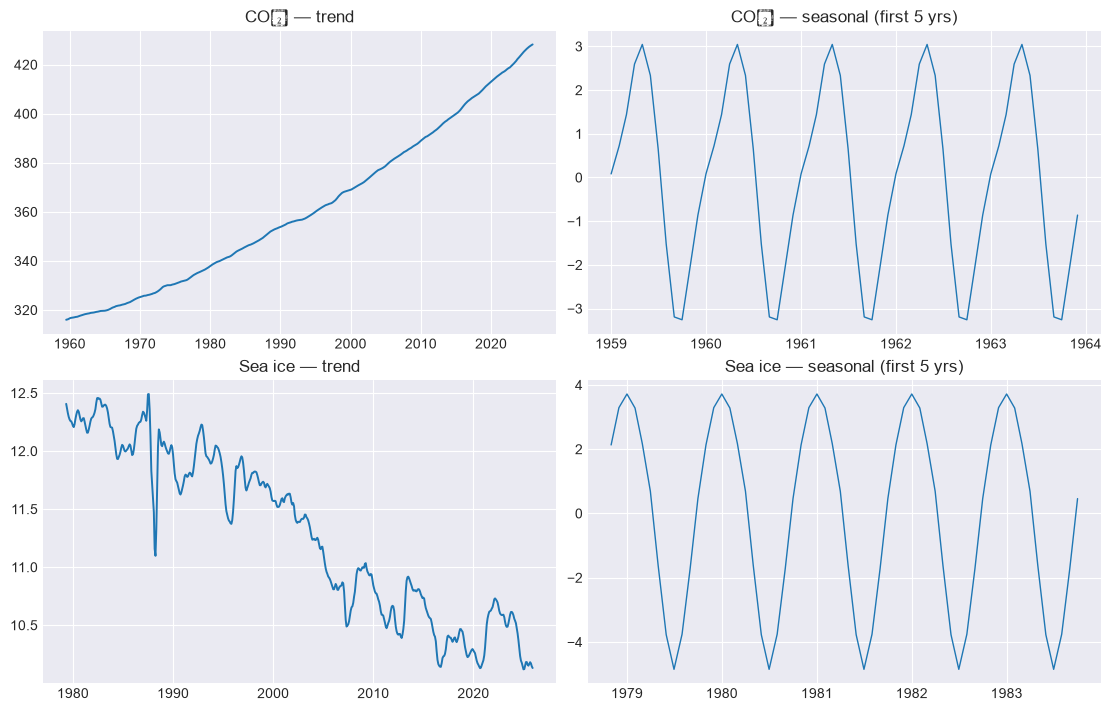

In [14]:
# ── EDA: diagnostics for model selection ────────────────────────────────────
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

def adf_report(name, series):
    s = series.dropna()
    stat, p, *_ = adfuller(s, autolag="AIC")
    verdict = "stationary" if p < 0.05 else "NON-stationary → difference"
    print(f"{name:26s} ADF p={p:.4f}  → {verdict}")

print("Augmented Dickey-Fuller (level series)\n" + "─" * 46)
adf_report("co2.deseasonalized",   co2["deseasonalized"])
adf_report("gistemp.anomaly",      gistemp["anomaly"])
adf_report("emissions.emissions_gt", emissions["emissions_gt"])
adf_report("seaice.extent",        seaice["extent"])

# Trend slope via OLS on time (per decade, in native units)
def trend_per_decade(name, series, scale="month"):
    s = series.dropna()
    t = (s.index.year + s.index.month / 12).to_numpy()
    t = t - t.min()
    slope = np.polyfit(t, s.to_numpy(), 1)[0]
    per = slope * 10
    print(f"{name:26s} {per:+.3f} / decade")

print("\nLinear trend (full record)\n" + "─" * 46)
trend_per_decade("co2.deseasonalized",   co2["deseasonalized"])
trend_per_decade("gistemp.anomaly",      gistemp["anomaly"])
trend_per_decade("emissions.emissions_gt", emissions["emissions_gt"])
trend_per_decade("seaice.extent",        seaice["extent"])

# Seasonal decomposition on the two strongly-seasonal monthly series
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for ax_row, (name, series) in zip(axes, [
        ("CO₂", co2["average"]),
        ("Sea ice", seaice["extent"])]):
    dec = seasonal_decompose(series.dropna(), model="additive", period=12)
    ax_row[0].plot(dec.trend, lw=1.4); ax_row[0].set_title(f"{name} — trend")
    ax_row[1].plot(dec.seasonal.iloc[:60], lw=1.0)
    ax_row[1].set_title(f"{name} — seasonal (first 5 yrs)")
plt.show()

In [15]:
# ── Modeling prep: split, metrics, baselines, features ─────────────────────
# Helpers only — no model fitting in this cell (that's the next phase).

def time_split(series, split_year=BACKTEST_SPLIT):
    """Split a datetime-indexed Series into train (<= split_year) / test (> it)."""
    s = series.dropna()
    cutoff = pd.Timestamp(year=split_year, month=12, day=31)
    return s[s.index <= cutoff], s[s.index > cutoff]

def regression_metrics(y_true, y_pred):
    """RMSE / MAE / MAPE for a holdout forecast."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

def seasonal_naive(train, test, period=12):
    """Baseline: predict each point as the value `period` steps earlier.
    Carries the last observed season through the test horizon."""
    history = list(train)
    preds = []
    for i in range(len(test)):
        preds.append(history[-period] if len(history) >= period else history[-1])
        history.append(preds[-1])  # recursive roll-forward
    return np.array(preds)

def make_time_features(index, period=12):
    """Design matrix for sklearn trend models: centered year + Fourier seasonality."""
    t = (index.year + (index.month - 1) / 12).to_numpy(dtype=float)
    t_c = t - t.mean()
    feats = {"t": t_c, "t2": t_c ** 2}  # quadratic captures CO2 acceleration
    for k in (1, 2):                    # first two harmonics
        feats[f"sin{k}"] = np.sin(2 * np.pi * k * t_c / period)
        feats[f"cos{k}"] = np.cos(2 * np.pi * k * t_c / period)
    return pd.DataFrame(feats, index=index)

# quick smoke check on one series (no fitting)
_tr, _te = time_split(co2["deseasonalized"])
print(f"co2 split: train {len(_tr)} pts (→{_tr.index.max():%Y-%m}), "
      f"test {len(_te)} pts ({_te.index.min():%Y-%m}→{_te.index.max():%Y-%m})")
print("feature matrix columns:", list(make_time_features(co2.index).columns))
print("\nHelpers ready. Next phase: fit candidates, backtest, select, forecast.")

co2 split: train 624 pts (→2010-12), test 186 pts (2011-01→2026-06)
feature matrix columns: ['t', 't2', 'sin1', 'cos1', 'sin2', 'cos2']

Helpers ready. Next phase: fit candidates, backtest, select, forecast.
